In [1]:
from math import pi

In [2]:
# %%timeit
'''
area of a circle solution -- OK to show students
'''
import random
import math

def estimate_circle_area(radius, num_samples):
    points_inside_circle = 0
    total_points = num_samples

    for _ in range(total_points):
        x = random.uniform(-radius, radius)
        y = random.uniform(-radius, radius)
        
        # Check if the point is inside the circle
        if x**2 + y**2 <= radius**2:
            points_inside_circle += 1
    
    # Area of the square is (2*radius)^2
    square_area = (2 * radius) ** 2
    # Estimate the area of the circle
    circle_area_estimate = (points_inside_circle / total_points) * square_area
    
    return circle_area_estimate

# Example usage:
radius = 1
num_samples = 100000
estimated_area = estimate_circle_area(radius, num_samples)
print(f"Estimated area of the circle: {estimated_area}")
print("Actual value of pi", pi)

Estimated area of the circle: 3.14652
Actual value of pi 3.141592653589793


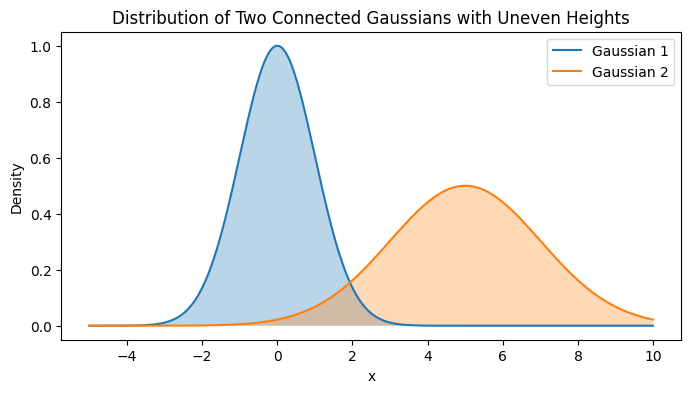

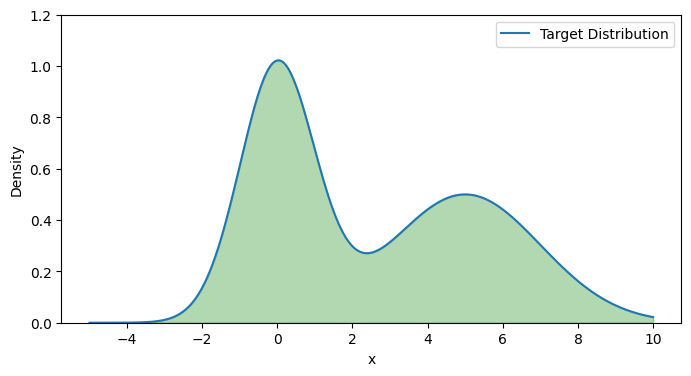

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters for two Gaussians
mean1, std1, height1 = 0, 1, 1  # First Gaussian
mean2, std2, height2 = 5, 2, 0.5  # Second Gaussian, shorter

# Generate points for the Gaussians
x = np.linspace(-5, 10, 400)
gaussian1 = height1 * np.exp(-((x - mean1) ** 2 / (2 * std1 ** 2)))
gaussian2 = height2 * np.exp(-((x - mean2) ** 2 / (2 * std2 ** 2)))

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(x, gaussian1, label='Gaussian 1')
plt.plot(x, gaussian2, label='Gaussian 2')
plt.fill_between(x, 0, gaussian1, alpha=0.3)
plt.fill_between(x, 0, gaussian2, alpha=0.3)
plt.title('Distribution of Two Connected Gaussians with Uneven Heights')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()


# Merging the two distributions
merged_gaussian = gaussian1 + gaussian2

# Plotting the merged distribution
plt.figure(figsize=(8, 4))
plt.plot(x, merged_gaussian, label='Target Distribution')
plt.fill_between(x, 0, merged_gaussian, alpha=0.3, color='green')
# plt.title('Merged Distribution of Two Gaussians')
plt.xlabel('x')
plt.ylim (0, 1.2)
plt.ylabel('Density')
plt.legend()
plt.show()


## Breakout: Markov-chain convergence

We will use a two-state market chain with states `Bull` and `Bear`. The transition matrix below is row-stochastic: each row is the current state, each column is the next state.

Tasks:

1. Write Python code and repeat this chain process for 5, 10, and 100 time steps. See when the stationary distribution is reached.
2. Try the initial state of a bear market.
3. Try any other initial state.
4. Do this with matrix multiplication.
5. Optional: do this with NumPy's eigenvector function. Remember the eigenvector is not normalized, and it needs to be normalized.

In [ ]:
import numpy as np
import pandas as pd

states = ["Bull", "Bear"]

P = np.array([
    [0.9, 0.3],
    [0.1, 0.7],
])

transition_table = pd.DataFrame(P, index=states, columns=states)
transition_table

,Bull,Bear
Bull,0.9,0.3
Bear,0.1,0.7


In [14]:
def evolve_distribution(initial_distribution, transition_matrix, steps):
    distribution = np.asarray(initial_distribution, dtype=float)
    for _ in range(steps):
        distribution = distribution @ transition_matrix
    return distribution


def chain_path(initial_distribution, transition_matrix, max_steps):
    rows = []
    distribution = np.asarray(initial_distribution, dtype=float)
    rows.append(distribution.copy())
    for _ in range(max_steps):
        distribution = distribution @ transition_matrix
        rows.append(distribution.copy())
    return pd.DataFrame(rows, columns=states).rename_axis("step")


def summarize_steps(initial_distribution, label, steps=(5, 10, 100)):
    results = []
    for n in steps:
        distribution = evolve_distribution(initial_distribution, P, n)
        results.append({
            "initial state": label,
            "steps": n,
            "Bull": distribution[0],
            "Bear": distribution[1],
        })
    return pd.DataFrame(results)

bull_start = np.array([1.0, 0.0])
summarize_steps(bull_start, "Bull")

,initial state,steps,Bull,Bear
0,Bull,5,0.769440,0.691680
1,Bull,10,0.751512,0.745465
2,Bull,100,0.750000,0.750000


In [15]:
# Part b: start in a bear market.
bear_start = np.array([0.0, 1.0])
summarize_steps(bear_start, "Bear")

,initial state,steps,Bull,Bear
0,Bear,5,0.230560,0.308320
1,Bear,10,0.248488,0.254535
2,Bear,100,0.250000,0.250000


In [16]:
# Part c: try another initial state.
# This could represent being 25% sure the economy starts in Bull and 75% sure it starts in Bear.
mixed_start = np.array([0.25, 0.75])
summarize_steps(mixed_start, "25% Bull / 75% Bear")

,initial state,steps,Bull,Bear
0,25% Bull / 75% Bear,5,0.365280,0.404160
1,25% Bull / 75% Bear,10,0.374244,0.377267
2,25% Bull / 75% Bear,100,0.375000,0.375000


In [17]:
# Part d: matrix multiplication gives the same result directly with P^n.
matrix_power_results = []
for n in [5, 10, 100]:
    distribution = bull_start @ np.linalg.matrix_power(P, n)
    matrix_power_results.append({
        "steps": n,
        "Bull": distribution[0],
        "Bear": distribution[1],
    })

pd.DataFrame(matrix_power_results)

,steps,Bull,Bear
0,5,0.769440,0.691680
1,10,0.751512,0.745465
2,100,0.750000,0.750000


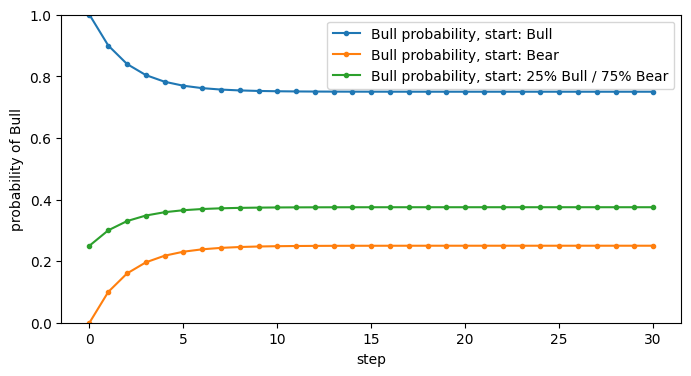

In [18]:
# Watch convergence over time from each starting state.
fig, ax = plt.subplots(figsize=(8, 4))

for initial_distribution, label in [
    (bull_start, "start: Bull"),
    (bear_start, "start: Bear"),
    (mixed_start, "start: 25% Bull / 75% Bear"),
]:
    path = chain_path(initial_distribution, P, 30)
    ax.plot(path.index, path["Bull"], marker="o", markersize=3, label=f"Bull probability, {label}")

ax.set_xlabel("step")
ax.set_ylabel("probability of Bull")
ax.set_ylim(0, 1)
ax.legend()
plt.show()

In [19]:
# Part e: stationary distribution using NumPy eigenvectors.
# For a row-stochastic matrix, the stationary distribution pi satisfies pi P = pi.
# That means pi is a left eigenvector of P with eigenvalue 1, or a right eigenvector of P.T.
eigenvalues, eigenvectors = np.linalg.eig(P.T)
stationary_index = np.argmin(np.abs(eigenvalues - 1))
stationary = np.real(eigenvectors[:, stationary_index])
stationary = stationary / stationary.sum()

stationary_table = pd.DataFrame({
    "state": states,
    "stationary probability": stationary,
})
stationary_table

,state,stationary probability
0,Bull,0.5
1,Bear,0.5


In [ ]:
comparison = pd.concat([
    summarize_steps(bull_start, "Bull", steps=(100,)),
    summarize_steps(bear_start, "Bear", steps=(100,)),
    summarize_steps(mixed_start, "25% Bull / 75% Bear", steps=(100,)),
], ignore_index=True)

comparison["distance from stationary"] = np.linalg.norm(
    comparison[["Bull", "Bear"]].to_numpy() - stationary,
    axis=1,
)
comparison

,initial state,steps,Bull,Bear,distance from stationary
0,Bull,100,0.750,0.750,0.353553
1,Bear,100,0.250,0.250,0.353553
2,25% Bull / 75% Bear,100,0.375,0.375,0.176777
